In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import gc

import sys
sys.path.append("..")
from helper_functions_260527 import import_flight_data

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import tensorflow as tf
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import callback

pd.set_option('display.max_columns',None)

radio_altitude = "radio_altitude"
vertical_acceleration = "vert_acc"

recompute = False
limit = 3140

In [98]:
# Step 1: Define turbulence data (= labels) ✓
# Step 2: Prepare wind data (= features) ✓
# Step 3: Join flight and wind data ✓
# Step 4: ML model ✓
# Step 5: Input feature ranking, tuning

### Step 1: Define turbulence data (= labels)

In [99]:
def trim_group(g):
    g = g.sort_values("Time (secs)")
    
    # find first index where altitude becomes valid
    valid_idx = g.index[g["radio_altitude"] > 1400]
    
    if len(valid_idx) == 0:
        return g.iloc[0:0]  # empty group
    
    start = valid_idx[0]
    return g.loc[start:]

aircraft_class_map = {
    "OY-GRP": "Medium",
    "OY-GRG": "Medium",
    "OY-GRO": "Medium",
    "OY-GRM": "Medium",
    "OY-GRJ": "Medium",
    "OY-GRH": "Medium",
    "OY-GRR": "Medium",
    "OY-GRK": "Medium",
    "OY-GKN": "Heavy",}

if recompute:
    path_flights = "/home/jovyan/work/AppliedML/FinalProject/Final_project_data/data/ML_data/NBI/FDM data/"
    df = import_flight_data(data_dir=path_flights,limit=limit,add_source_file=True,filter=False)

    # Remove everything where Radio Altitude > 1500 ft or below 0
    df[radio_altitude] = df[radio_altitude].ffill()
    df = df[df[radio_altitude] <= 1500]
    df = df[df[radio_altitude] >= 0]

    # Remove years before 2024
    df["year"] = df["year"].ffill()
    df = df[df["year"] >= 2024.0]

    # Remove departures, if there are any
    df = df[~df["source_file"].str.contains("Dep",na=False)]

    # Is the plane heavy or not?
    df["aircraft_id"] = df["source_file"].str.extract(r"(OY-[A-Z]+)")[0]
    df["aircraft_class"] = df["aircraft_id"].map(aircraft_class_map)
    df["aircraft_is_heavy"] = (df["aircraft_class"] == "Heavy").astype(int)
    df = df.drop(["aircraft_id"],axis=1); df = df.drop(["aircraft_class"],axis=1)

    # For easier readability, introduce landing_id and drop source_file
    df["landing_id"] = pd.factorize(df["source_file"])[0]
    #df = df.drop(["source_file"],axis=1)

    # Calculate direction of approach (this may cause trouble around 360/0°)
    df["Magnetic Heading"] = df["Magnetic Heading"].ffill()
    df["mean_heading"] = df.groupby("landing_id")["Magnetic Heading"].transform("mean")
    df = df.drop(["Magnetic Heading"],axis=1)

    # Remove erroneous data points and finally, reset the indices
    df = df.groupby("landing_id", group_keys=False).apply(trim_group)
    df = df.reset_index(drop=True)

    # Calculate how much vertical accelaration deviates from 1
    df['vert_acc_dev'] = abs(df['vert_acc'] - 1.0)
    
    # Calculate std, max and maximum jump of vertical acceleration per landing
    turbulence_per_landing_std = df.groupby("landing_id")["vert_acc_dev"].std()
    turbulence_per_landing_max = df.groupby("landing_id")["vert_acc"].max()
    turbulence_per_landing_max_jump = df.groupby("landing_id")["vert_acc"].apply(lambda x: x.diff().abs().max())
    turbulence_per_landing_p90 = df.groupby("landing_id")["vert_acc_dev"].quantile(0.9)
    turbulence_per_landing_p95 = df.groupby("landing_id")["vert_acc_dev"].quantile(0.95)

    show_extras = False
    if show_extras:
        for name, group in df.groupby("landing_id"):
            plt.plot(group["radio_altitude"], marker="o", label=name)
        plt.grid()
        plt.legend()
        for file, grp in df.groupby("landing_id"):
            print(grp[["Time (secs)","radio_altitude"]].head())

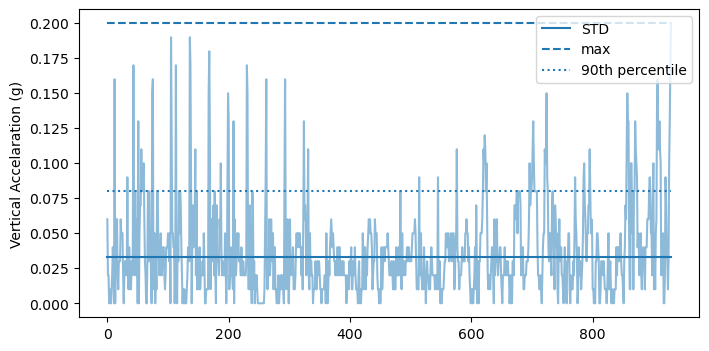

In [100]:
fig, ax = plt.subplots(1,1,figsize=(8,4))

for name, group in df.groupby("landing_id"):
    test = abs(np.array(group["vert_acc"]) - 1)
    ax.plot(test,alpha=0.5)
    ax.plot(np.std(test)*np.ones(len(test)),color="tab:blue",label="STD")
    ax.plot(np.max(test)*np.ones(len(test)),color="tab:blue",linestyle="--",label="max")
    ax.plot(np.percentile(test,90)*np.ones(len(test)),color="tab:blue",linestyle="dotted",label="90th percentile")
    
#ax.axhline(y=1,linewidth=0.67,color="k")
ax.set_ylabel("Vertical Accelaration (g)")
#ax.set_ylim(0.78,1.22)
ax.legend(loc="upper right")

### Step 2: Prepare wind data (= labels)

In [4]:
if recompute:
    # Fill all the fields related to time
    times = ["year","month","day","hour","minute","second"]
    df[times] = df[times].ffill()

    # Find out the time when each landing starts
    landing_starts = df.groupby("landing_id").head(1).reset_index(drop=True)
    
    # Generate the filenames for the corresponding wind data files
    landing_starts["wind_file_name"] = (
        "TWI-" + landing_starts["year"].astype(int).astype(str) + "-" +
        landing_starts["month"].astype(int).astype(str).str.zfill(2) + "-" +
        landing_starts["day"].astype(int).astype(str).str.zfill(2) +
        "_UTC_log.csv"
    )

    # Generate datetime columns to be consistent with wind data
    landing_starts["landing_time"] = pd.to_datetime(
        dict(
            year=landing_starts["year"].astype(int),
            month=landing_starts["month"].astype(int),
            day=landing_starts["day"].astype(int),
            hour=landing_starts["hour"].astype(int),
            minute=landing_starts["minute"].astype(int),
            second=landing_starts["second"].astype(int),
        )
    )

if recompute:
    path_wind = "/home/jovyan/work/AppliedML/FinalProject/Final_project_data/data/ML_data/TWI data/"
    wind_data = {}
    for file_name in landing_starts["wind_file_name"].unique():
        file_path = Path(path_wind)/file_name
        wind_df = pd.read_csv(file_path, sep=";")
        wind_df["DateTime"] = pd.to_datetime(wind_df["DateTime"])
        wind_data[file_name] = wind_df

In [5]:
if recompute:
    wind_variables = [
        'W04.VectorMeanWindSpeed',
        'W04.VectorMeanWindDirection',
        'W04.ScalarMaxWindSpeed',
        #'W04.ScalarMaxWindAtDirection',
        'W04.ScalarMeanWindSpeed',
        'W04.ScalarWindSpeedDeviation',
        #'W04.ScalarMeanWindDirection',
        #'W04.ScalarWindDirectionDeviation',
        'W04.LastWindSpeed',
        #'W04.LastWindDirection',
        'W22.VectorMeanWindSpeed',
        #'W22.VectorMeanWindDirection',
        'W22.ScalarMaxWindSpeed',
        #'W22.ScalarMaxWindAtDirection',
        'W22.ScalarMeanWindSpeed',
        'W22.ScalarWindSpeedDeviation',
        #'W22.ScalarMeanWindDirection',
        'W22.ScalarWindDirectionDeviation',
        'W22.LastWindSpeed',
        #'W22.LastWindDirection'
    ]

    # How many minutes to look back
    wind_windows = [60,15,5]
    feature_rows = []

    for _, landing in landing_starts.iterrows():
        landing_id = landing["landing_id"]
        landing_time = landing["landing_time"]
        wind_df = wind_data[landing["wind_file_name"]] #wind_df = wind_data[landing_id] More memory-friendly?

        features = {"landing_id": landing_id}
        for minutes in wind_windows:
            window_start = landing_time - pd.Timedelta(minutes=minutes)
            window = wind_df[(wind_df["DateTime"] >= window_start) & (wind_df["DateTime"] < landing_time)]
            # Statistical quantities, many of them are probably a bit nonsense
            for col in wind_variables:
                prefix = f"{col}_{minutes}m"
                features[f"{prefix}_mean"] = window[col].mean()
                features[f"{prefix}_std"] = window[col].std()
                features[f"{prefix}_max"] = window[col].max()
                features[f"{prefix}_range"] = window[col].max() - window[col].min()
            # Gust (defined as ratio or difference of max wind speed to mean wind speed)
            for runway in ["W04","W22"]:
                max_speed = window[f"{runway}.ScalarMaxWindSpeed"].mean()
                mean_speed = window[f"{runway}.ScalarMeanWindSpeed"].mean()
                features[f"{runway}_gust_factor_{minutes}m"] = (max_speed - mean_speed)
                features[f"{runway}_gust_ratio_{minutes}m"] = (max_speed/mean_speed if mean_speed > 0 else np.nan)
            # Changes in wind direction
            for runway in ["W04", "W22"]:
                for direction_col in [f"{runway}.VectorMeanWindDirection",f"{runway}.ScalarMeanWindDirection",f"{runway}.LastWindDirection"]:
                    directions = window[direction_col].dropna()
                    if len(directions) > 1:
                        circular_jumps = ((directions.diff().abs() + 180) % 360 - 180).abs()
                        prefix = f"{direction_col}_{minutes}m"
                        features[f"{prefix}_mean_change"] = circular_jumps.mean()
                        features[f"{prefix}_max_change"] = circular_jumps.max()
                    else:
                        prefix = f"{direction_col}_{minutes}m"
                        features[f"{prefix}_mean_change"] = np.nan
                        features[f"{prefix}_max_change"] = np.nan
            # Difference between W04 and W22 sensors as a proxy for spatial variability
            sensor_pairs = [
                ("VectorMeanWindSpeed", "speed"),
                ("ScalarMeanWindSpeed", "scalar_speed"),
                ("ScalarMaxWindSpeed", "max_speed"),
                ("LastWindSpeed", "last_speed"),]
            for variable, short_name in sensor_pairs:
                w04 = window[f"W04.{variable}"].mean()
                w22 = window[f"W22.{variable}"].mean()
                features[f"{short_name}_sensor_diff_{minutes}m"] = abs(w04 - w22)
            # Circular encoding of wind directions
            direction_columns = [
                "W04.VectorMeanWindDirection",
                "W04.ScalarMeanWindDirection",
                "W04.LastWindDirection",
                "W22.VectorMeanWindDirection",
                "W22.ScalarMeanWindDirection",
                "W22.LastWindDirection",]
            for col in direction_columns:
                radians = np.deg2rad(window[col])
                prefix = f"{col}_{minutes}m"
                features[f"{prefix}_sin_mean"] = np.sin(radians).mean()
                features[f"{prefix}_cos_mean"] = np.cos(radians).mean()

        feature_rows.append(features)

    wind_features = pd.DataFrame(feature_rows)

### Step 4: ML model

#### Load all the data

In [6]:
if recompute:
    extra_landing_features = df.groupby("landing_id", as_index=False)[["source_file","aircraft_is_heavy","mean_heading","month","hour"]].first()
    landing_metrics = pd.concat([
        turbulence_per_landing_std.rename("turbulence_std"),
        turbulence_per_landing_max.rename("turbulence_max"),
        turbulence_per_landing_max_jump.rename("turbulence_max_jump"),
        turbulence_per_landing_p90.rename("turbulence_p90"),
        turbulence_per_landing_p95.rename("turbulence_p95")],axis=1).reset_index()
    landing_metrics = landing_metrics.merge(extra_landing_features,on="landing_id")
    DATA = wind_features.merge(landing_metrics,on="landing_id")
    DATA.to_csv("DATA%s.csv" %limit,index=False)
else:
    DATA = pd.read_csv("DATA%s.csv" %limit)

X = DATA.drop(columns=["landing_id","turbulence_std","turbulence_max","turbulence_max_jump","turbulence_p90","turbulence_p95","source_file"])
y = DATA["turbulence_std"]

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [ column for column in upper.columns if any(upper[column] > 0.95) ]
X_reduced = X.drop(columns=to_drop)

X_train, X_test, y_train, y_test = train_test_split(X_reduced,y,test_size=0.2,random_state=42)
X_train_train, X_valid, y_train_train, y_valid = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

#### Permutation importance (with Random Forest)

In [7]:
rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1)
    
rf.fit(X_train_train,y_train_train)

perm_importance = permutation_importance(
    rf,
    X_valid,
    y_valid,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_absolute_error") 

importance_df = pd.DataFrame({
    "Variable": X_valid.columns,
    "Importance": perm_importance.importances_mean})

importance_df = importance_df.sort_values(by="Importance",ascending=False)
top20_input_variables = importance_df.head(50)["Variable"]

print(top20_input_variables)

14         W22.ScalarWindSpeedDeviation_60m_mean
95                                  mean_heading
50          W22.ScalarWindSpeedDeviation_15m_max
16          W22.ScalarWindSpeedDeviation_60m_max
19                   W22.LastWindSpeed_60m_range
15          W22.ScalarWindSpeedDeviation_60m_std
7          W04.ScalarWindSpeedDeviation_60m_mean
53                     W22.LastWindSpeed_15m_std
12              W22.VectorMeanWindSpeed_60m_mean
35      W22.VectorMeanWindDirection_60m_sin_mean
67      W04.VectorMeanWindDirection_15m_sin_mean
0               W04.VectorMeanWindSpeed_60m_mean
11                   W04.LastWindSpeed_60m_range
96                                         month
8           W04.ScalarWindSpeedDeviation_60m_std
46                   W04.LastWindSpeed_15m_range
9           W04.ScalarWindSpeedDeviation_60m_max
5          W04.VectorMeanWindDirection_60m_range
79       W22.ScalarWindDirectionDeviation_5m_std
92                          speed_sensor_diff_5m
89     W22.ScalarMea

#### XGBoost

In [8]:
model = XGBRegressor(
    n_estimators=100,
    #max_depth=3,
    learning_rate=0.1,
    random_state=42)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_})

importance = importance.sort_values("importance",ascending=False)
print(importance.head(30))

R²: 0.2785606744107285
RMSE: 0.010903799807653887
                                       feature  importance
16        W22.ScalarWindSpeedDeviation_60m_max    0.172350
53                   W22.LastWindSpeed_15m_std    0.044180
14       W22.ScalarWindSpeedDeviation_60m_mean    0.035549
50        W22.ScalarWindSpeedDeviation_15m_max    0.034618
46                 W04.LastWindSpeed_15m_range    0.022203
45                   W04.LastWindSpeed_15m_std    0.022070
11                 W04.LastWindSpeed_60m_range    0.020914
95                                mean_heading    0.016311
19                 W22.LastWindSpeed_60m_range    0.015006
96                                       month    0.014764
20                          W04_gust_ratio_60m    0.013142
54                          W04_gust_ratio_15m    0.012845
15        W22.ScalarWindSpeedDeviation_60m_std    0.012641
89   W22.ScalarMeanWindDirection_5m_max_change    0.012618
10                   W04.LastWindSpeed_60m_std    0.011971
39    

In [9]:
param_dist = {
    'n_estimators':   [50, 100, 200, 300],        # number of trees
    'max_depth':      [3, 4, 5, 6, 7],            # how deep each tree can grow
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],     # step size shrinkage
    'subsample':      [0.6, 0.7, 0.8, 1.0],       # fraction of samples per tree
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],     # fraction of features per tree
}

xgb_base = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,           # try 30 random combinations
    cv=5,                # 5-fold cross validation
    scoring='r2',        # optimise for R²
    random_state=42,
    verbose=1,           # print progress
    n_jobs=-1            # use all CPU cores
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best R²:", random_search.best_score_.round(4))

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("R²:", round(r2_score(y_test, y_pred), 4))
print("RMSE:", round(mean_squared_error(y_test, y_pred)**0.5, 4))

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_})

importance = importance.sort_values("importance", ascending=False)
print("\nTop 30 features:")
print(importance.head(30))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best R²: 0.3603
R²: 0.3071
RMSE: 0.0107

Top 30 features:
                                       feature  importance
16        W22.ScalarWindSpeedDeviation_60m_max    0.099668
50        W22.ScalarWindSpeedDeviation_15m_max    0.078474
14       W22.ScalarWindSpeedDeviation_60m_mean    0.039489
46                 W04.LastWindSpeed_15m_range    0.022851
15        W22.ScalarWindSpeedDeviation_60m_std    0.019749
19                 W22.LastWindSpeed_60m_range    0.019375
95                                mean_heading    0.019063
53                   W22.LastWindSpeed_15m_std    0.015558
42              W04.ScalarMaxWindSpeed_15m_std    0.015290
9         W04.ScalarWindSpeedDeviation_60m_max    0.014967
45                   W04.LastWindSpeed_15m_std    0.014332
96                                       month    0

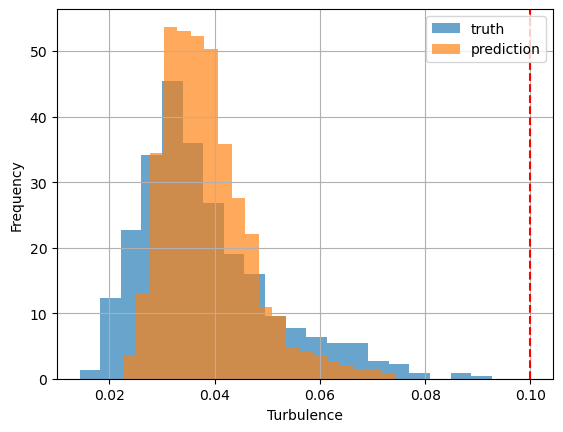

In [10]:
plt.hist(y_test,bins=20,alpha=0.67,label="truth",density=True)
plt.hist(y_pred,bins=20,alpha=0.67,label="prediction",density=True)

plt.axvline(x=0.1,color="red",linestyle="--")

plt.xlabel("Turbulence")
plt.ylabel("Frequency")

plt.legend(loc="upper right")
plt.grid()

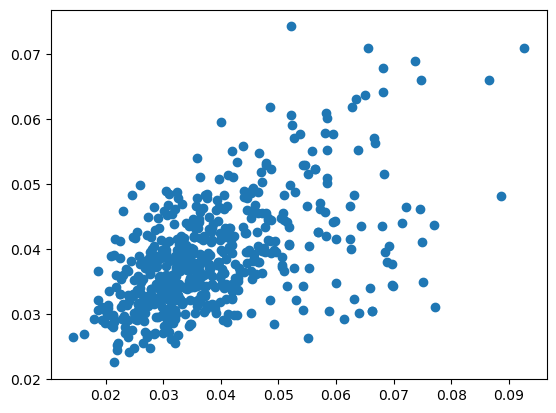

In [11]:
plt.scatter(y_test,y_pred)

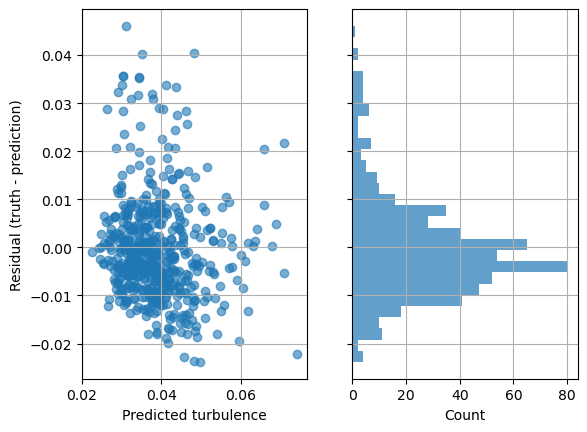

In [12]:
fig, axs = plt.subplots(1,2,sharey=True)

axs[0].scatter(y_pred, y_test - y_pred, alpha=0.6)
axs[0].set_xlabel("Predicted turbulence")
axs[0].set_ylabel("Residual (truth - prediction)")
axs[0].grid()

axs[1].hist( y_test - y_pred,bins=30,orientation="horizontal",alpha=0.7)
axs[1].set_xlabel("Count")
axs[1].grid()

plt.show()